In [111]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    else:
        return torch.device("cpu")
device = get_device()

In [112]:
# 1. Initialization
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.13.0+cu130
CUDA available: True


In [113]:
# 2. Revision

# Q1
a = torch.randn(4, 3)
result_1 = a.unsqueeze(1) # Shape: (4,1,3)
assert(result_1.shape == (4,1,3))

# Q2
a = torch.randn(4, 3)
b = torch.randn(5, 3)
result_2 = a.unsqueeze(1) - b.unsqueeze(0) # Shape: (4,5,3)
assert(result_2.shape == (4,5,3))

# Q3
x = torch.randn(2, 3, 4)
result_3 = x.permute(2, 0, 1) # Shape: (4, 2, 3)
assert(result_3.shape == (4,2,3))

# Q4
x = torch.randn(2, 3, 4)
result_4 = x[:, 1:2, :].reshape(2, -1) # Shape: (2,4)
assert(result_4.shape == (2,4))

# Q5
images = torch.randn(8, 3, 32, 32)
result_5 = (images.permute(0, 2, 3, 1).reshape(8, -1)) # Shape: (8, 3072)
assert(result_5.shape == (8,3072))

points_a: `(N,D)`\
points_a after singleton insertion: `(N,1,D)`

points_b: `(M,D)`\
points_b after singleton insertion: `(1,M,D)`

difference: `(N,M,D)`\
sum over feature dimension: `(N,M)`

# 3. Gradient by hand

For a function

$L = (wx+b-y)^2$

Derive the gradient with respect to $w$ and $b$

For a scalar linear model:
$$\hat{y} = wx+b$$
And loss function:
$$L = (\hat{y}-y)^2$$
Where
- $x$ and $y$ are fixed data values.
- $w$ and $b$ are trainable params.
- $\hat{y}$ is model pred
- $L$ is the scalar loss

Let
$$ e = \hat{y}-y$$
Let
$$ u = wx+b $$

Computation graph:
```
w ──┐
    u ── e  ── L
b ──┘
```

$\frac{\partial{L}}{\partial{w}} = \frac{\partial{L}}{\partial{e}} \cdot \frac{\partial{e}}{\partial{u}} \cdot \frac{\partial{u}}{\partial{w}} = 2e \cdot 1 \cdot x = 2(wx + b - y)x$

$\frac{\partial{L}}{\partial{b}} = \frac{\partial{L}}{\partial{e}} \cdot \frac{\partial{e}}{\partial{u}} \cdot \frac{\partial{u}}{\partial{b}} = 2e \cdot 1 \cdot 1 = 2(wx + b - y)$

Hand verification:\
$x=3$\
$y=7$\
$w=2$\
$b=−1$

Prediction = 5\
Residual = -2\
Loss = 4\
$\frac{\partial{L}}{\partial{w}} = -12$\
$\frac{\partial{L}}{\partial{b}} = -4$

In [114]:
x = 3.0
y = 7.0
w = 2.0
b = -1.0

prediction = w * x + b
error = prediction - y
loss = error**2

manual_dw = 2 * error * x
manual_db = 2 * error

assert prediction == 5.0
assert error == -2.0
assert loss == 4.0
assert manual_dw == -12.0
assert manual_db == -4.0

In [115]:
# 4. Raw-tensor linear regression

# Generate synthetic data with 3 features. Pre-determined true_w and true_b.

torch.manual_seed(7)

num_examples = 1_000
num_features = 3

x_cpu = torch.randn(num_examples, num_features)

true_w_cpu = torch.tensor([2.0, -1.0, 0.5])
true_b_cpu = torch.tensor(3.0)

noise_cpu = 0.1 * torch.randn(num_examples)

y_cpu = (
    x_cpu @ true_w_cpu
    + true_b_cpu
    + noise_cpu
)

x = x_cpu.to(device)
y = y_cpu.to(device)
true_w = true_w_cpu.to(device)
true_b = true_b_cpu.to(device)

In [116]:
print(x.shape)          # (N,D)
print(y.shape)          # (N,)
print(true_w.shape)     # (D,)
print(true_b.shape)     # ()

torch.Size([1000, 3])
torch.Size([1000])
torch.Size([3])
torch.Size([])


In [117]:
assert x.shape == (num_examples, num_features)
assert y.shape == (num_examples,)
assert true_w.shape == (num_features,)
assert true_b.ndim == 0

assert x.device == device
assert y.device == device
assert true_w.device == device
assert true_b.device == device

In [118]:
w = torch.zeros(
    num_features,
    device=device,
    requires_grad=True,
)

b = torch.zeros(
    (),
    device=device,
    requires_grad=True
)

print(type(w))
print(type(b))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


Initial values should be:

w.requires_grad: `True`\
w.is_leaf: `True`\
w.grad before backward: `None`

b.requires_grad: `True`\
b.is_leaf: `True`\
b.grad before backward: `None`

In [119]:
print(f"{w.requires_grad=}, {w.is_leaf=}, {w.grad=}")
print(f"{b.requires_grad=}, {b.is_leaf=}, {b.grad=}")

w.requires_grad=True, w.is_leaf=True, w.grad=None
b.requires_grad=True, b.is_leaf=True, b.grad=None


In [120]:
# Validating a single backward pass

prediction = x @ w + b          # Shape: (N,1)
residual = prediction - y       # Shape: (N,1)
loss = (residual**2).mean()     # Shape: (N,1)

In [121]:
assert prediction.shape == (num_examples,)
assert residual.shape == (num_examples,)
assert loss.shape == ()

In [122]:
print(f"{prediction.requires_grad=}")   # If gradient is tracked
print(f"{prediction.is_leaf=}")         # If is a leaf in computational graph
print(f"{prediction.grad_fn=}")         # Check gradient function

print(f"{loss.requires_grad=}")
print(f"{loss.is_leaf=}")
print(f"{loss.grad_fn=}")

prediction.requires_grad=True
prediction.is_leaf=False
prediction.grad_fn=<AddBackward0 object at 0x7f1a4da6cfd0>
loss.requires_grad=True
loss.is_leaf=False
loss.grad_fn=<MeanBackward0 object at 0x7f1a4c1397b0>


The mean squared loss is:
$$ L = \frac{1}{N} \sum_{i=1}^{N}(\hat{y}_{i}-y_{i})^2$$
Weight gradient is:
$$ \frac{\partial(L)}{\partial(w)} = \frac{2}{N} X^{T}(\hat{y}-y)$$
Bias gradient is:
$$ \frac{\partial(L)}{\partial(b)} = \frac{2}{N} \sum_{i=1}^{N}(\hat{y}_{i}-y_{i})$$

In [123]:
# Expected w_grad & b_grad

# torch.no_grad() Disable tracking computational history / prevent new tensors
# from being added to the computational graph
with torch.no_grad(): 
    expected_w_grad = (2.0 / num_examples) * (x.T @ residual)
    expected_b_grad = (2.0 / num_examples) * residual.sum()

In [124]:
# After backward(), Python frees the graph's saved intermediate tensors
# unless graph retention was requested. 

loss.backward()

In [125]:
assert w.grad.shape == w.shape
assert b.grad.shape == b.shape

# Asserting expected gradient matches actual gradient.

assert torch.allclose(
    w.grad,
    expected_w_grad,
    atol=1e-5
)

assert torch.allclose(
    b.grad,
    expected_b_grad,
    atol=1e-5
)

print(f"{w.grad} {b.grad}")

tensor([-3.9184,  1.7195, -1.0061], device='cuda:0') -5.799296855926514


In [126]:
w.grad.zero_()
b.grad.zero_()

tensor(0., device='cuda:0')

In [127]:
# Re-setup our linear regression model

torch.manual_seed(7)

num_examples = 1_000
num_features = 3

x_cpu = torch.randn(num_examples, num_features)

true_w_cpu = torch.tensor([2.0, -1.0, 0.5])
true_b_cpu = torch.tensor(3.0)

noise_cpu = 0.1 * torch.randn(num_examples)

y_cpu = (
    x_cpu @ true_w_cpu
    + true_b_cpu
    + noise_cpu
)

x = x_cpu.to(device)
y = y_cpu.to(device)
true_w = true_w_cpu.to(device)
true_b = true_b_cpu.to(device)

w = torch.zeros(
    num_features,
    device=device,
    requires_grad=True,
)

b = torch.zeros(
    (),
    device=device,
    requires_grad=True
)

print(type(w))
print(type(b))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [128]:
# Hyper param setup

learning_rate = 0.05
max_epoch = 300

loss_history: lists[float] = []

In [129]:
for epoch in range(1,max_epoch + 1):
    prediction = x @ w + b
    loss = ((prediction-y)**2).mean()

    loss.backward()

    with torch.no_grad():
        w -= w.grad * learning_rate     # Cannot be an assignment during update
        b -= b.grad * learning_rate     # Cannot be an assignment during update
    
    w.grad.zero_()
    b.grad.zero_()

    # loss.item() Return value of tensor as python element
    # Only applies with tensor with one element
    loss_history.append(loss.item())

    if epoch % 25 == 0:
        print(
            f"step={epoch:03d} "
            f"loss={loss.item():.6f}"
        )

step=025 loss=0.117122
step=050 loss=0.011272
step=075 loss=0.010587
step=100 loss=0.010582
step=125 loss=0.010582
step=150 loss=0.010582
step=175 loss=0.010582
step=200 loss=0.010582
step=225 loss=0.010582
step=250 loss=0.010582
step=275 loss=0.010582
step=300 loss=0.010582


In [130]:
final_loss = loss_history[-1]

print(f"Final loss: {final_loss:.6f}")
print(f"Learned w: {w.detach().cpu()}")
print(f"True w:    {true_w.detach().cpu()}")
print(f"Learned b: {b.detach().cpu().item():.6f}")
print(f"True b:    {true_b.detach().cpu().item():.6f}")

Final loss: 0.010582
Learned w: tensor([ 2.0012, -1.0046,  0.5035])
True w:    tensor([ 2.0000, -1.0000,  0.5000])
Learned b: 2.994354
True b:    3.000000


In [131]:
assert final_loss < 0.02

assert torch.allclose(
    w.detach(),
    true_w,
    atol=0.05,
)

assert torch.allclose(
    b.detach(),
    true_b,
    atol=0.05,
)

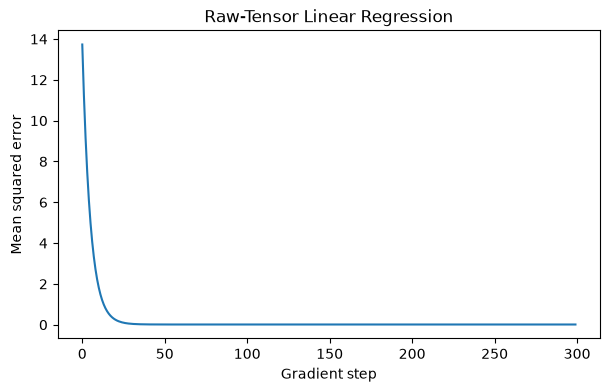

In [132]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Gradient step")
plt.ylabel("Mean squared error")
plt.title("Raw-Tensor Linear Regression")
plt.show()

For this block of code
```python
prediction = x @ w + b
loss = ((prediction - y) ** 2).mean()
loss.backward()

with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

w.grad.zero_()
b.grad.zero_()
```

It first creates two intermediate tensors prediction & loss.

Calling loss.backward() performs backpropagation, clearing all intermediate tensors, and computes gradients for nodes where requires_grad=True

inside `with torch.no_grad():`, we update tensor `w` and `b` without adding a new node to compute graph.

And then we clear accumulated gradient for both `w` and `b`.

In [133]:
# Demonstrate graph accumulation

p = torch.tensor(3.0, requires_grad=True)

first_loss = p**2
first_loss.backward()

first_gradient = p.grad.clone()
print(f"After first backward: {p.grad}")

second_loss = p**2
second_loss.backward()

second_gradient = p.grad.clone()
print(f"After second backward: {p.grad}")

After first backward: 6.0
After second backward: 12.0


In [134]:
# Expect .grad to accumulate 6.0 twice

assert torch.allclose(
    first_gradient,
    torch.tensor(6.0),
)

assert torch.allclose(
    second_gradient,
    torch.tensor(12.0),
)

p.grad.zero_()
assert p.grad.item() == 0.0

In [135]:
# Demonstrate backward() tensor clear, and failure if calling backward() twice

q = torch.tensor(2.0, requires_grad=True)
same_graph_loss = q**3

same_graph_loss.backward()

try:
    same_graph_loss.backward()
except RuntimeError as exc:
    print(type(exc).__name__)
    print(str(exc).splitlines()[0])

RuntimeError
Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.


In [136]:
# Comparing .detach() and torch.no_grad()

source = torch.tensor(2.0, requires_grad=True)
tracked = source * 3

# Returns a new tensor, detached from computation graph containing it
detached = tracked.detach()

assert tracked.requires_grad
assert tracked.grad_fn is not None

assert not detached.requires_grad
assert detached.grad_fn is None

In [137]:
# Prevents tracking inside an entire region
# (prevents operations inside the scope from being considered in computation graph)
with torch.no_grad():
    untracked_a = source * 3
    untracked_b = untracked_a + 5

assert not untracked_a.requires_grad
assert not untracked_b.requires_grad

In [138]:
# Safe and unsafe history changes

tracked_losses = []

temporary = (source * 4) ** 2
tracked_losses.append(temporary)

# Appended item is actually a tensor connected to computation graph
assert tracked_losses[0].grad_fn is not None

In [139]:
numeric_losses = []
numeric_losses.append(temporary.item())

# Now item is a plain python type
assert isinstance(numeric_losses[0], float)

In [140]:
# Duplicating a tensor, detached from computation history.
detached_snapshot = temporary.detach().clone()

assert not detached_snapshot.requires_grad
assert detached_snapshot.grad_fn is None

In [141]:
# In-place parameter update rule

r = torch.tensor(1.0, requires_grad=True)

# In-place mutation is forbidden for leaf nodes while not detached.
try:
    r -= 0.1
except RuntimeError as exc:
    print(type(exc).__name__)
    print(str(exc).splitlines()[0])

RuntimeError
a leaf Variable that requires grad is being used in an in-place operation.


In [142]:
with torch.no_grad():
    r -= 0.1

assert torch.allclose(
    r,
    torch.tensor(0.9),
)

assert r.is_leaf
assert r.requires_grad